In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader, SubsetRandomSampler
from sklearn.metrics import classification_report
import time
import os
import numpy as np
from sklearn.model_selection import train_test_split # 추가된 라이브러리
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# 🌟 추가된 부분: 그래프를 그리기 위한 라이브러리 임포트 🌟
import matplotlib.pyplot as plt

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("lantian773030/pokemonclassification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'pokemonclassification' dataset.
Path to dataset files: /kaggle/input/pokemonclassification


In [3]:
# GPU 설정 (Colab 환경 최적화)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"사용 중인 디바이스: {device}")

사용 중인 디바이스: cuda:0


In [4]:
# 1. 데이터 준비 (데이터 경로를 본인의 Colab 환경에 맞게 수정하세요)
data_dir = path+"/PokemonData" # 경로
num_classes = 150 # 과제 명세서 기준
batch_size = 64 # GPU 메모리에 맞춰 64~128로 조절해 학습 속도를 높이세요.

In [5]:
# ImageNet Pre-trained 모델들의 입력 크기에 맞춘 Transform[cite: 2]
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

In [6]:
# 데이터로더 생성 (실제 데이터셋 경로 지정 필요)
# 3. Train/Val 폴더가 따로 없으므로, 동일한 경로에서 Transform만 다르게 두 번 불러옵니다.
train_dataset = datasets.ImageFolder(data_dir, transform=data_transforms['train'])
val_dataset = datasets.ImageFolder(data_dir, transform=data_transforms['val'])

In [7]:
# 4. Stratified Split (클래스 비율을 유지하며 8:2 분할)
targets = train_dataset.targets # 각 이미지의 클래스 라벨들
train_idx, val_idx = train_test_split(
    np.arange(len(targets)),
    test_size=0.2,
    shuffle=True,
    stratify=targets, # 핵심: 클래스 비율을 유지
    random_state=42
)

In [8]:
# 5. 분할된 인덱스를 바탕으로 Sampler 생성
train_sampler = SubsetRandomSampler(train_idx)
val_sampler = SubsetRandomSampler(val_idx)

In [9]:
# 6. 최종 DataLoader 생성 (Sampler를 사용하므로 shuffle=True는 뺍니다)
dataloaders = {
    'train': DataLoader(train_dataset, batch_size=64, sampler=train_sampler, num_workers=2),
    'val': DataLoader(val_dataset, batch_size=64, sampler=val_sampler, num_workers=2)
}

# ⭐ 7. (가장 중요) 학습 루프에서 나눌 때 사용할 실제 데이터 개수 저장
dataset_sizes = {
    'train': len(train_idx),
    'val': len(val_idx)
}

print(f"총 데이터 개수: {len(targets)}")
print(f"학습용(Train) 데이터 개수: {dataset_sizes['train']}")
print(f"검증용(Val) 데이터 개수: {dataset_sizes['val']}")

총 데이터 개수: 6820
학습용(Train) 데이터 개수: 5456
검증용(Val) 데이터 개수: 1364


In [10]:
# 2. 분류기 생성 함수 (4개의 실험 세팅)
def set_parameter_requires_grad(model, feature_extracting):
    if feature_extracting:
        for param in model.parameters():
            param.requires_grad = False

In [11]:
def initialize_model(model_name, num_classes, feature_extract=True, use_pretrained=True):
    model_ft = None

    if model_name == "resnet18_extract":
        # Classifier 1: ResNet-18 Feature Extraction
        weights = models.ResNet18_Weights.DEFAULT if use_pretrained else None
        model_ft = models.resnet18(weights=weights)
        set_parameter_requires_grad(model_ft, feature_extract)
        num_ftrs = model_ft.fc.in_features
        model_ft.fc = nn.Linear(num_ftrs, num_classes) # 마지막 레이어는 학습되도록 requires_grad=True

    elif model_name == "resnet18_finetune":
        # Classifier 2: ResNet-18 Partial Fine-tuning (layer4만 동결 해제)
        weights = models.ResNet18_Weights.DEFAULT if use_pretrained else None
        model_ft = models.resnet18(weights=weights)
        set_parameter_requires_grad(model_ft, feature_extract)
        # layer4(마지막 Conv 블록)의 파라미터는 학습하도록 변경
        for param in model_ft.layer4.parameters():
            param.requires_grad = True
        num_ftrs = model_ft.fc.in_features
        model_ft.fc = nn.Linear(num_ftrs, num_classes)

    elif model_name == "googlenet":
        # Classifier 3: GoogLeNet Feature Extraction
        weights = models.GoogLeNet_Weights.DEFAULT if use_pretrained else None
        model_ft = models.googlenet(weights=weights)
        set_parameter_requires_grad(model_ft, feature_extract)
        num_ftrs = model_ft.fc.in_features
        model_ft.fc = nn.Linear(num_ftrs, num_classes)

    elif model_name == "mobilenet_v2":
        # Classifier 4: MobileNetV2 Feature Extraction
        weights = models.MobileNet_V2_Weights.DEFAULT if use_pretrained else None
        model_ft = models.mobilenet_v2(weights=weights)
        set_parameter_requires_grad(model_ft, feature_extract)
        num_ftrs = model_ft.classifier[1].in_features
        model_ft.classifier[1] = nn.Linear(num_ftrs, num_classes)

    return model_ft

In [12]:
from tqdm import tqdm

# 3. 모델 학습 함수 (간략화된 템플릿)
def train_model(model, dataloaders, criterion, optimizer, num_epochs=10):
    since = time.time()

    # 🌟 추가된 부분: 학습 기록을 저장할 딕셔너리 생성 🌟
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            if phase == 'val':
                all_preds = []
                all_labels = []

            # 데이터를 GPU로 이동[cite: 2]
            for inputs, labels in tqdm(dataloaders[phase]):
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    _, preds = torch.max(outputs, 1)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

                # 🌟 추가된 부분 2: Validation 중일 때 예측값과 정답을 리스트에 계속 누적 🌟
                # (GPU에 있는 텐서를 CPU로 내리고 numpy 배열로 변환해서 저장)
                if phase == 'val':
                    all_preds.extend(preds.cpu().numpy())
                    all_labels.extend(labels.cpu().numpy())

            # ⭐ 버그 수정: len(dataloaders[phase].dataset) 대신 dataset_sizes[phase] 사용
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]
            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # 🌟 추가된 부분: 매 Epoch마다 기록 저장하기 🌟
            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc)
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc)

            # 🌟 추가된 부분 3: Validation 1개 Epoch이 끝날 때마다 성능 지표 계산 및 출력 🌟
            if phase == 'val':
                # 포켓몬 데이터는 150개의 클래스(다중 분류)이므로 average 파라미터가 필수입니다.
                # 'macro'는 각 클래스별 지표를 구한 뒤 단순 평균을 냅니다.
                val_acc = accuracy_score(all_labels, all_preds)
                val_prec = precision_score(all_labels, all_preds, average='macro', zero_division=0)
                val_rec = recall_score(all_labels, all_preds, average='macro', zero_division=0)
                val_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)

                print(f'-> [Val Metrics] Accuracy: {val_acc:.4f} | Precision: {val_prec:.4f} | Recall: {val_rec:.4f} | F1-Score: {val_f1:.4f}\n')

    time_elapsed = time.time() - since
    print(f'학습 완료 시간: {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    return model, history

In [13]:
def to_cpu(data_list):
    return [x.cpu().numpy() if torch.is_tensor(x) else x for x in data_list]

def plot_learning_curve(history, num_epochs):
    epochs = range(1, num_epochs + 1)

    plt.figure(figsize=(12, 5))

    # Loss 그래프 (to_cpu 적용)
    plt.subplot(1, 2, 1)
    plt.plot(epochs, to_cpu(history['train_loss']), label='Train Loss', marker='o')
    plt.plot(epochs, to_cpu(history['val_loss']), label='Validation Loss', marker='o')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Accuracy 그래프 (to_cpu 적용)
    plt.subplot(1, 2, 2)
    plt.plot(epochs, to_cpu(history['train_acc']), label='Train Accuracy', marker='o')
    plt.plot(epochs, to_cpu(history['val_acc']), label='Validation Accuracy', marker='o')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()



In [14]:
# 실험할 모델 이름 목록: ["resnet18_extract", "resnet18_finetune", "googlenet", "mobilenet_v2"]
experiment_name = "resnet18_extract"

# 모델 초기화 및 GPU 적재
model_net = initialize_model(experiment_name, num_classes=150)
model_net = model_net.to(device)

# Loss 함수 및 Optimizer 설정
criterion = nn.CrossEntropyLoss()

# 파라미터 업데이트 설정 (requires_grad가 True인 것만 학습)
params_to_update = [p for p in model_net.parameters() if p.requires_grad]
optimizer_ft = optim.Adam(params_to_update, lr=0.001)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 146MB/s]


Epoch 0/4
----------


100%|██████████| 86/86 [00:42<00:00,  2.05it/s]


train Loss: 4.5174 Acc: 0.1131


100%|██████████| 22/22 [00:11<00:00,  1.86it/s]


val Loss: 3.5024 Acc: 0.3556
-> [Val Metrics] Accuracy: 0.3556 | Precision: 0.4535 | Recall: 0.3427 | F1-Score: 0.3013

Epoch 1/4
----------


...

val Loss: 1.5359 Acc: 0.7229
-> [Val Metrics] Accuracy: 0.7229 | Precision: 0.7821 | Recall: 0.7183 | F1-Score: 0.7184

Epoch 4/4
----------


100%|██████████| 86/86 [00:31<00:00,  2.76it/s]


train Loss: 1.5955 Acc: 0.7088


100%|██████████| 22/22 [00:09<00:00,  2.34it/s]


val Loss: 1.3276 Acc: 0.7507
-> [Val Metrics] Accuracy: 0.7507 | Precision: 0.7849 | Recall: 0.7457 | F1-Score: 0.7414

학습 완료 시간: 3m 35s


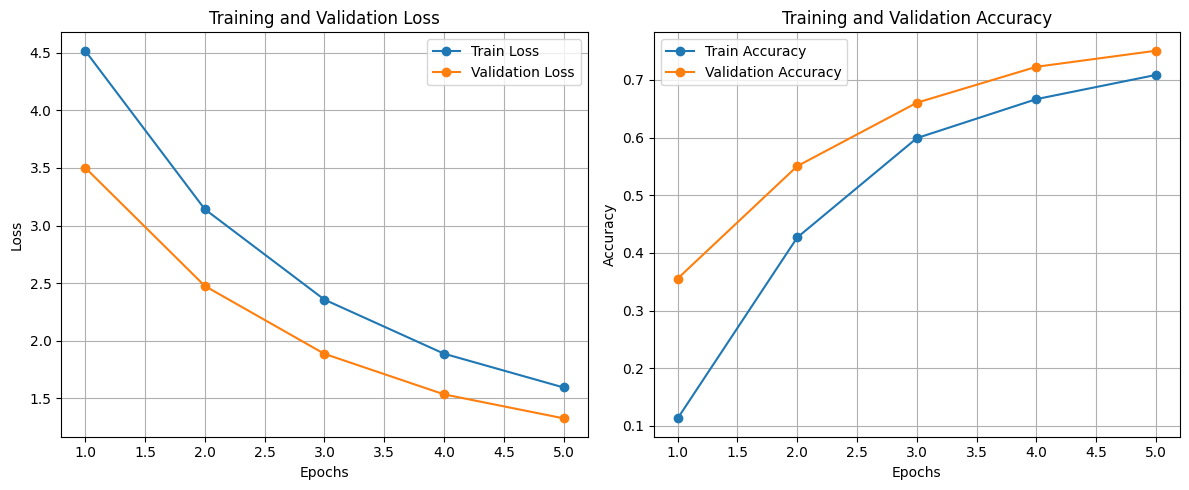

In [15]:
# 학습 실행 (주석 해제 후 사용하세요)
num_epochs = 5
trained_model, training_history = train_model(model_net, dataloaders, criterion, optimizer_ft, num_epochs=num_epochs)

# 학습 곡선 출력
plot_learning_curve(training_history, num_epochs)

In [16]:
# 학습된 모델의 가중치 저장
torch.save(model_net.state_dict(), 'It\'s_Pikachu_resnet18_extract.pth')

# 클래스 이름(포켓몬 이름) 목록 저장 (나중에 예측 결과 출력용)
class_names = train_dataset.classes
import json
with open('class_names.json', 'w') as f:
    json.dump(class_names, f)